In [2]:
import dask.dataframe as dd

file_path_1 = r"C:\Users\Alejandro\Downloads\sample_data_0006_part_00.parquet"
file_path_2 = r"C:\Users\Alejandro\Downloads\sample_data_0007_part_00.parquet"

# Leer archivos Parquet con Dask
ddf1 = dd.read_parquet(file_path_1)
ddf2 = dd.read_parquet(file_path_2)

# Concatenar y eliminar duplicados
ddf = dd.concat([ddf1, ddf2]).drop_duplicates(subset=["_id"])

# Para ver el tamaño aproximado (número de filas)
print(ddf.shape)  # Esto devuelve (Delayed('int...'), 8) usualmente
# Para ver las primeras filas (atención con la memoria)
print(ddf.head())

# Convertir fechas
ddf['transaction_date'] = dd.to_datetime(ddf['transaction_date'])



# Cuando quieras computar algo
result = ddf.compute() 
print(result.shape)
print(result.info())



(<dask_expr.expr.Scalar: expr=(DropDuplicates(frame=Concat(frames=[ReadParquetFSSpec(b33ffeb), ReadParquetFSSpec(3600f4d)], ), subset=['_id'])).size() // 8, dtype=int64>, 8)
                         merchant_id                               _id  \
4   075d178871d8d48502bf1f54887e52fe  0ce7ab2950e7a788a608f881aec0f8f0   
9   075d178871d8d48502bf1f54887e52fe  76d975dce75647824a3ff3d1c8e4fa4c   
11  075d178871d8d48502bf1f54887e52fe  e26fbeabe859434b0625aeda2bf43dc3   
19  075d178871d8d48502bf1f54887e52fe  2dac45c2318f3a0ef105c3021c4c9a77   
29  075d178871d8d48502bf1f54887e52fe  cc24fd073206a0352a9bd9599af1d824   

                          subsidiary    transaction_date  \
4   971e55ef12d80ec070ea4f6750c8b892 2021-09-12 18:31:07   
9   30e5a216a97f0b59114d79b0b69061a2 2021-09-12 18:29:45   
11  4329e57e3f9f7517cca9922ac2302a46 2021-09-12 18:29:42   
19  197c0d5d3ec9a83de9d82cbbbcb53375 2021-09-12 18:28:59   
29  acf7e14e0d613c2fb5697a94fcd2045e 2021-09-12 18:27:30   

                    

In [3]:
# Convertir columnas a tipos compatibles
ddf["transaction_amount"] = ddf["transaction_amount"].astype(float)
ddf["transaction_date"] = dd.to_datetime(ddf["transaction_date"])
ddf["user_id"] = ddf["user_id"].astype(str)
ddf["day_bucket"] = ddf["transaction_date"].dt.floor("D")

# Función para agrupar por partición
def process_partition(partition):
    partition["day_bucket"] = partition["transaction_date"].dt.floor("D")
    grouped = partition.groupby(["user_id", "account_number", "day_bucket"]).agg({
        "transaction_amount": ["count", "sum", "std"]
    })
    grouped.columns = ["rolling_count", "rolling_sum", "rolling_std"]
    return grouped.reset_index()

# Aplicar la función a cada partición
grouped = ddf.map_partitions(process_partition)
grouped = grouped.reset_index()


In [4]:
# Exportar particiones como CSV
for i, partition in enumerate(grouped.to_delayed()):
    partition.compute().to_csv(f"grouped_results_part_{i}.csv", index=False)

In [5]:
import pandas as pd
import glob

# Ruta donde están los CSV parciales
csv_files = glob.glob("grouped_results_part_*.csv")

# Leer y combinar los archivos
combined_df = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

# Exportar el archivo combinado
combined_df.to_csv("grouped_results_combined.csv", index=False)
print("Archivo combinado generado: grouped_results_combined.csv")

Archivo combinado generado: grouped_results_combined.csv


In [6]:
pip install seaborn


In [6]:
print(combined_df["rolling_sum"].describe())

count    2.035195e+07
mean     2.022394e+02
std      2.585554e+02
min      5.944455e+00
25%      4.755564e+01
50%      1.188891e+02
75%      2.377782e+02
max      1.010557e+04
Name: rolling_sum, dtype: float64


count    2.035179e+07
mean     2.022409e+02
std      2.585668e+02
min      5.944455e+00
25%      4.755564e+01
50%      1.188891e+02
75%      2.377782e+02
max      1.010557e+04
Name: rolling_sum, dtype: float64


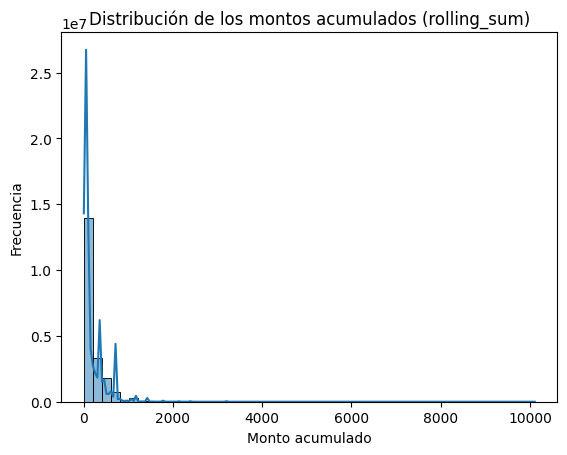

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estadísticas descriptivas
print(combined_df["rolling_sum"].describe())

# Visualización
sns.histplot(combined_df["rolling_sum"], bins=50, kde=True)
plt.title("Distribución de los montos acumulados (rolling_sum)")
plt.xlabel("Monto acumulado")
plt.ylabel("Frecuencia")
plt.show()

In [7]:
percentil_95 = combined_df["rolling_sum"].quantile(0.95)
percentil_99 = combined_df["rolling_sum"].quantile(0.99)
print("Umbral 95%:", percentil_95)
print("Umbral 99%:", percentil_99)


Umbral 95%: 713.33460148
Umbral 99%: 1188.89100247


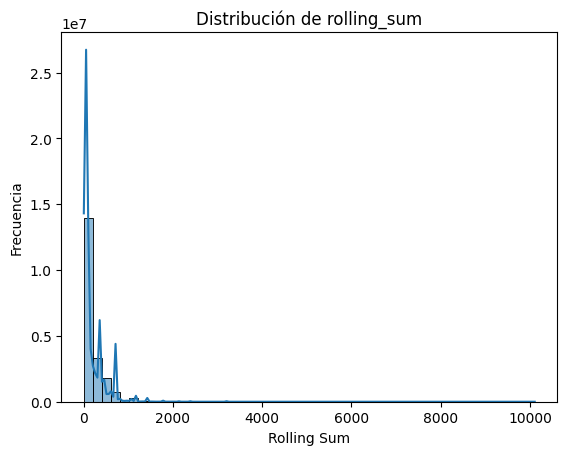

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(combined_df["rolling_sum"], bins=50, kde=True)
plt.title("Distribución de rolling_sum")
plt.xlabel("Rolling Sum")
plt.ylabel("Frecuencia")
plt.show()

In [31]:
umbral_final = 1188.89  # Percentil 99

# Identificar fraccionamientos
fraccionamiento = combined_df[
    (combined_df["rolling_count"] > 1) & 
    (combined_df["rolling_sum"] > umbral_final)
]

# Reportar resultados
print(f"Transacciones identificadas como fraccionamiento: {len(fraccionamiento)}")
fraccionamiento.to_csv("fraccionamiento_detectado.csv", index=False)

Transacciones identificadas como fraccionamiento: 93451


In [8]:
fraccionamiento = combined_df[combined_df["rolling_count"] > 1]
print(f"Transacciones identificadas como fraccionamiento: {len(fraccionamiento)}")
fraccionamiento.to_csv("fraccionamiento_detectado.csv", index=False)


Transacciones identificadas como fraccionamiento: 586914


In [28]:
fraccionamiento[["user_id", "hour_bucket", "rolling_count", "rolling_sum"]]


,user_id,hour_bucket,rolling_count,rolling_sum
47,0001385060dcdeba8a32e4ee5f34b9dd,2021-04-04,2,47.555640
86,0002838f641a0a719f2d731dee7cd914,2021-03-13,2,153.366939
96,0002ad97e3f83b08a57f8fb018e747fb,2021-11-09,2,1070.001902
109,00030e8a4d8d2ee1cc9742c36f54a4f9,2021-02-08,2,118.889100
172,00041bcc4da8e05a91b09bba4a514ba1,2021-09-07,2,237.778200
...,...,...,...,...
20351621,fff8cff1d7a14fdc32b63b1e5dba35f3,2021-02-12,3,1177.002092
20351673,fffa0b57c33a5deed0ae31b3f90d86db,2021-04-29,2,47.555640
20351851,fffe3a1cb68eea2bfd7dc8eed9c945a7,2021-02-07,2,83.222370
20351852,fffe52f156c69127e28e3c7bc9e65ed7,2021-10-16,2,475.556401


In [29]:
grouped = ddf.groupby(["user_id", "account_number", "hour_bucket"]).agg({
    "transaction_amount": ["count", "sum", "std"]
})
grouped.columns = ["rolling_count", "rolling_sum", "rolling_std"]
grouped = grouped.reset_index()


In [10]:
# Filtrar fraccionamientos por usuario y ventana de 24 horas
fraccionamiento = combined_df[
    (combined_df["rolling_count"] > 1)  # Más de una transacción
]

# Mostrar resultados relevantes
print(f"Transacciones fraccionadas detectadas: {len(fraccionamiento)}")
print(fraccionamiento[["user_id", "account_number","day_bucket", "rolling_count", "rolling_sum"]].head())

# Exportar los datos para validación
fraccionamiento.to_csv("transacciones_sospechosas.csv", index=False)
fraccionamiento.info()

Transacciones fraccionadas detectadas: 586914
                              user_id                    account_number  \
47   0001385060dcdeba8a32e4ee5f34b9dd  6b5434039e05855a582ce88a6946e4a2   
86   0002838f641a0a719f2d731dee7cd914  8d407bfb7366f630e7efd79a5854ff8b   
96   0002ad97e3f83b08a57f8fb018e747fb  a1d8544693837bb384991d01d03f4ee2   
109  00030e8a4d8d2ee1cc9742c36f54a4f9  a1f4fc6e48a4f6ccc57daf2c22d7b3e5   
172  00041bcc4da8e05a91b09bba4a514ba1  81fe5d2cb614c0ac7e7bcd793ddc1798   

     day_bucket  rolling_count  rolling_sum  
47   2021-04-04              2    47.555640  
86   2021-03-13              2   153.366939  
96   2021-11-09              2  1070.001902  
109  2021-02-08              2   118.889100  
172  2021-09-07              2   237.778200  
<class 'pandas.core.frame.DataFrame'>
Index: 586914 entries, 47 to 20351897
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   index           586914

In [11]:
usuarios_sospechosos = fraccionamiento["user_id"].nunique()
print(f"Total de usuarios con transacciones sospechosas: {usuarios_sospechosos}")


Total de usuarios con transacciones sospechosas: 293138


In [12]:
cuentas_sospechosas = fraccionamiento.groupby("account_number").size()
print(f"Distribución de transacciones sospechosas por cuenta:\n{cuentas_sospechosas.describe()}")


Distribución de transacciones sospechosas por cuenta:
count    293626.000000
mean          1.998849
std           4.308121
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         261.000000
dtype: float64


In [13]:
print(combined_df["rolling_sum"].describe())


count    2.035195e+07
mean     2.022394e+02
std      2.585554e+02
min      5.944455e+00
25%      4.755564e+01
50%      1.188891e+02
75%      2.377782e+02
max      1.010557e+04
Name: rolling_sum, dtype: float64


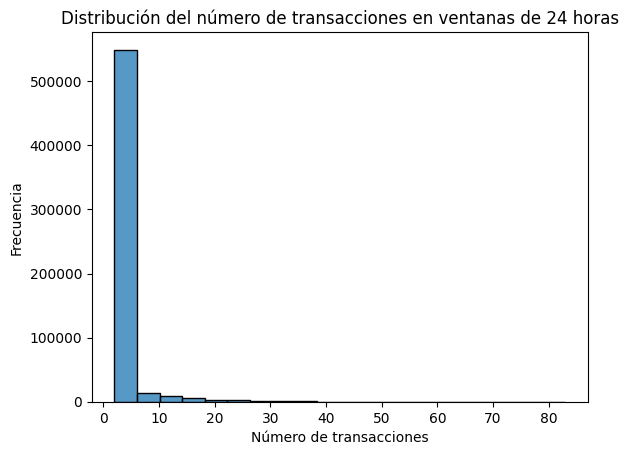

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(fraccionamiento["rolling_count"], bins=20, kde=False)
plt.title("Distribución del número de transacciones en ventanas de 24 horas")
plt.xlabel("Número de transacciones")
plt.ylabel("Frecuencia")
plt.show()


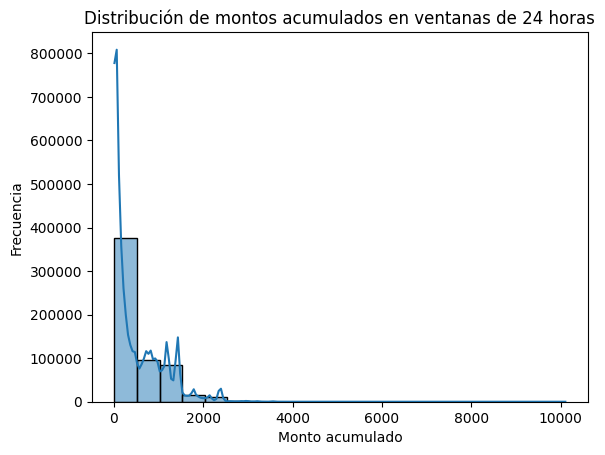

In [15]:
sns.histplot(fraccionamiento["rolling_sum"], bins=20, kde=True)
plt.title("Distribución de montos acumulados en ventanas de 24 horas")
plt.xlabel("Monto acumulado")
plt.ylabel("Frecuencia")
plt.show()


In [29]:
# Ordenar datos por usuario y fecha de transacción
fraccionamiento = fraccionamiento.sort_values(by=['user_id', 'day_bucket'])


In [31]:
# Métrica 3: Número de cuentas destino únicas por usuario en 24 horas
metric_3 = fraccionamiento.groupby(['user_id', 'day_bucket'])['account_number'].nunique()
metric_3

user_id                           day_bucket
0000180e94707c0d90547614c17076bf  2021-09-05    1
0000551498c521d0eb863e006c2a3a5b  2021-11-23    1
0000ed9f5e1bdc0515bdc25954cf4f09  2021-04-27    1
0000f65abdddc8de930a36c0da53a9df  2021-03-18    1
                                  2021-03-25    1
                                               ..
ffff5c196cd98d76659ac68c87beefb3  2021-04-03    1
                                  2021-08-18    1
ffff5d8d9deaa1e844c4d4585d21b409  2021-11-10    1
ffff9d74b3b9249dca43ea7a13824f41  2021-09-25    1
ffffecb14c622ff657fb8668300c7540  2021-10-01    1
Name: account_number, Length: 502593, dtype: int64

In [3]:
pip install "dask[distributed]

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 9.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
from dask.distributed import Client

# Conectar a un clúster local
client = Client(n_workers=4, threads_per_worker=2, memory_limit="2GB")
print(client)

<Client: 'tcp://127.0.0.1:63473' processes=4 threads=8, memory=7.45 GiB>
